In [1]:
import parcels
import copernicusmarine
import xarray as xr
import numpy as np
import gsw
import matplotlib.pyplot as plt

In [2]:
copernicus_args = {
    "start_datetime": "2025-06-10",
    "end_datetime": "2025-06-12",
    "minimum_longitude": -49,
    "maximum_longitude": -42,
    "minimum_latitude": 18,
    "maximum_latitude": 26,
    "service": "arco-geo-series",
    "chunk_size_limit": 1,
}

ds_uv = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m",
    variables=["uo", "vo"],
    **copernicus_args,
)

ds_w = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy-wcur_anfc_0.083deg_P1D-m",
    variables=["wo"],
    **copernicus_args,
)

ds_s = copernicusmarine.open_dataset(
  dataset_id="cmems_mod_glo_phy-so_anfc_0.083deg_P1D-m",
  variables=["so"],
  **copernicus_args,
)

ds_t = copernicusmarine.open_dataset(
  dataset_id="cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m",
  variables=["thetao"],
  **copernicus_args,
)

# combine into one dataset
ds = parcels.convert.copernicusmarine_to_sgrid(
    fields={
        "U": ds_uv["uo"],
        "V": ds_uv["vo"],
        "W": ds_w["wo"],
        "S": ds_s["so"],
        "T": ds_t["thetao"],
    }
)

# explicitly load dataset
ds.load()
display(ds)

# convert to parcels fieldset
fieldset = parcels.FieldSet.from_sgrid_conventions(ds)
fieldset.to_chunk_cached_arrays()
# fieldset.describe()  # DEBUG very slow

INFO - 2026-10-05T07:59:19Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  c.vanrijswijk@uu.nl


Copernicus Marine password:

  ········


...

  c.vanrijswijk@uu.nl


Copernicus Marine password:

  ········


INFO - 2026-10-05T08:00:13Z - Selected dataset version: "202406"
INFO - 2026-10-05T08:00:13Z - Selected dataset part: "default"


<xarray.Dataset> Size: 25MB
Dimensions:  (depth: 50, lat: 97, lon: 85, time: 3)
Coordinates:
  * depth    (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * lat      (lat) float32 388B 18.0 18.08 18.17 18.25 ... 25.83 25.92 26.0
  * lon      (lon) float32 340B -49.0 -48.92 -48.83 ... -42.17 -42.08 -42.0
  * time     (time) datetime64[ns] 24B 2025-06-10 2025-06-11 2025-06-12
Data variables:
    U        (time, depth, lat, lon) float32 5MB -0.1567 -0.1614 ... nan nan
    V        (time, depth, lat, lon) float32 5MB -0.03323 0.0005089 ... nan nan
    W        (time, depth, lat, lon) float32 5MB -1.565e-07 -4.483e-07 ... nan
    S        (time, depth, lat, lon) float32 5MB 37.04 36.97 36.91 ... nan nan
    T        (time, depth, lat, lon) float32 5MB 26.17 26.22 26.26 ... nan nan
    grid     int64 8B 0

In [ ]:
    # simple model, for small bubbles < 2.6 mm (McGinnis et al., 2006)
    mu = 0.001 # Pa s
    L = 1 # m
    Re = particles.risevel*rho_f*L/mu # Reynolds number
    CD = 24/Re + 3/Re**0.5 + 0.34 # drag coefficient
    d = 1e-3 # 1 mm size of bubble
    #particles.risevel = (4*d*g*(1 - rho_b/rho_f)/(3*CD))**0.5

In [28]:
R = 8.314462618 # J/(mol K), gas constant
M_H2 = 2.01588e-3 # kg/mol
g = 9.81  # Acceleration due to gravity in m/s^2

def PT_to_T(PT, P, S, lat, lon):
    SA = gsw.SA_from_SP(S, P, lon, lat) # absolute salinity
    CT = gsw.CT_from_pt(SA, PT) # conservative temp
    T = gsw.t_from_CT(SA, CT, P) # temperature
    return T
    
def dyn_viscosity(S, T):
    S = S / 1000 # S in kg/kg
    mu_water = 4.2844e-5 + (0.157*(T + 64.993)**2 - 91.296)**(-1) 

    I = 19.915*S / (1 - 1.00487*S) # ionic strength
    log10mswmw = 0.0428*I + 0.00123*I**2 + 0.000131*I**3 + (-0.03724*I + 0.01859*I**2 - 0.00271*I**3)*np.log10(1e3*mu_water)
    mu_seawater = mu_water*10**(log10mswmw)
    return mu_seawater

def surface_tension(S, T):
    sigma_seawater = 75.59 - 0.13476*T + 0.021352*S - 0.00029529*S*T
    return sigma_seawater/1000 # sigma in N/m

def bubble_density(P, T):
    # from ideal gas law, only valid at moderate depths
    # TODO: implement version in deep ocean, and maybe not a pure H2 bubble?
    P_Pa = (P + 10.1325) * 1e4 # pressure in Pa from dbar
    T_K = T + 273.15 # temperature in K from C
    return M_H2*P_Pa / (R*T_K)

def reynolds_number(u, d_b, rho_l, mu_l):
    """
    Reynolds number Re = rho_l * |u_rel| * d_b / mu_l.
    u_rel: relative velocity (fluid - bubble) [m/s]
    d_b: bubble diameter [m]
    rho_l: liquid density [kg/m^3]
    mu_l: liquid dynamic viscosity [Pa·s]
    """
    return rho_l * np.abs(u) * d_b / mu_l

def eotvos_number(d_b, rho_l, rho_b, sigma):
    """
    Eötvös number Eo = (rho_l - rho_b) * g * d_b^2 / sigma.
    d_b: bubble diameter [m]
    rho_l: liquid density [kg/m^3]
    rho_b: bubble gas density [kg/m^3]
    sigma: surface tension [N/m]
    """
    return (rho_l - rho_b) * g * d_b**2 / sigma  

def drag_coefficient(Re, Eo, alpha = 0):
    CD0 = np.maximum(
        np.minimum(24/Re * (1 + 0.15*Re**0.687), 72/Re),
        8/3 * Eo/(Eo + 4))
    CD = CD0*(1 - (3*alpha / np.pi)**(2/3)) # alpha = volume fraction, TODO: implement expression for alpha
    return CD

In [96]:
# H2 solubility modelling in seawater (implementing eq. 18 from paper Olsen)
def mass_transfer_coefficient_zy(U, d_e, D = 5e-9): # implement expression for D, molecular diffusivity, from Claude.ai
    """
    Zheng & Yapa (2002) mass transfer coefficient, combining Johnson et al. (1969)
    and Clift et al. (1978), by bubble shape regime.
    Inputs in SI units (U: m/s, D: m^2/s, d_e: m). Returns K in m/s.
    Internally converts to cm/s, cm^2/s, cm as the correlation requires.
    """
    U_cm  = U * 100.0
    D_cm  = D * 1.0e4
    de_cm = d_e * 100.0

    K_small = 0.0113*np.sqrt(U_cm*D_cm / (0.45 + 0.2*de_cm))      # Eq. (4), de<=5mm
    K_mid   = 0.065*np.sqrt(D_cm)                                  # Eq. (5), 5<de<=13mm
    K_large = 0.0694*de_cm**(-0.25)*np.sqrt(D_cm)                  # Eq. (6), de>13mm

    K_cm = np.where(de_cm <= 0.5, K_small,
                     np.where(de_cm <= 1.3, K_mid, K_large))
    return K_cm / 100.0   # back to m/s

def solubility_hydrogen(S, T):
    # solubility of H2 according to Wiesenburg and Guinasso, 1979, requires T in Kelvin, S in parts per thousand
    T_K = T + 273.15
    A1, A2, A3 = -47.8948, 65.0368, 20.1709
    B1, B2, B3 = -0.082225, 0.049564, -0.0078689
    lnbeta = (A1 + A2*(100.0/T_K) + A3*np.log(T_K/100.0)
              + S*(B1 + B2*(T_K/100.0) + B3*(T_K/100.0)**2))
    return np.exp(lnbeta)

def c_sol_from_bunsen(beta, p_partial_Pa, M): # from Claude.ai
    """
    Converts a Bunsen coefficient to an equilibrium mass concentration c_sol [kg/m^3]
    at a given partial pressure of the gas species.
    beta * p/p0 = volume of gas (STP) dissolved per volume of water.
    n = (beta * p/p0) / Vm_STP  [mol gas / m^3 water], Vm_STP = 0.022414 m^3/mol
    """
    p0 = 101325.0
    Vm_STP = 0.022414
    n = beta * (p_partial_Pa/p0) / Vm_STP     # mol/m^3
    print(Vm_STP, beta, p_partial_Pa)
    return n * M   

In [99]:
H2Particle = parcels.Particle.add_variable(
    [
        parcels.Variable("temp", dtype=np.float32, initial=np.nan),
        parcels.Variable("salt", dtype=np.float32, initial=np.nan),
        parcels.Variable("density", dtype=np.float32, initial=np.nan),
        parcels.Variable("risevel", dtype=np.float32, initial=0.01),
        parcels.Variable('wprev', dtype = np.float32, initial=np.nan),
        parcels.Variable('d',  dtype=np.float32, initial=1e-3),   # initial bubble diameter
        parcels.Variable('mb', dtype=np.float32, initial=8e-9),    # set from d0, rho_b0 at release
    ]
)

# This is where the science happens - how to define rise velocity?
def Rising(particles, fieldset):
    salt = fieldset.S[particles] # psu
    temp = fieldset.T[particles] # degrees Celsius (pot. T)
    pressure = gsw.p_from_z(-particles.z, particles.y)
    print(pressure)
    p_abs = (pressure + 10.1325)* 1e4 # dbar to Pa
    rho_f = gsw.density.rho(salt, temp, pressure)
    w = fieldset.W[particles]

    T = PT_to_T(temp, pressure, salt, particles.y, particles.x)
    mu = dyn_viscosity(salt, T) # dynamic viscosity seawater
    rho_b = bubble_density(pressure, T)  # bubble density, calculated using ideal gas law
    sigma = surface_tension(salt, T) # surface tension seawater, in N/m
    Re = reynolds_number(w - particles.risevel, particles.d, rho_f, mu)
    Eo = eotvos_number(particles.d, rho_f, rho_b, sigma)
    CD = drag_coefficient(Re, Eo)
    C_VM = .5

    DuDt = np.where(particles.wprev == particles.wprev,     
                (w - particles.wprev) / particles.dt, 0.0)
    particles.wprev = w

    # equation parts
    A = g * (rho_b - rho_f) / rho_b     # first term
    k = 18 * mu /(rho_b * particles.d**2) * CD * Re /24.
    r = C_VM*rho_f/rho_b
    m = 1 + r

    # solubility
    k_H2 = mass_transfer_coefficient_zy(particles.risevel, particles.d)
    beta = solubility_hydrogen(salt, temp)

    c_sol_H2 = c_sol_from_bunsen(beta, p_abs, M_H2)
    c_w = 0.0 # undersaturated ocean
    
    m_dot = np.pi*particles.d**2 * k_H2 * (c_sol_H2 - c_w)
    print(m_dot, k_H2, c_sol_H2)
    mb_new = particles.mb - m_dot*particles.dt
    mb_new = np.maximum(mb_new, 0.0)
    print(mb_new)
    particles.mb = mb_new
    particles.d = (6*mb_new/(np.pi*rho_b))**(1/3)
    print(particles.d)
    
    particles.risevel = (m*particles.risevel + particles.dt*(A + k*w + r*DuDt)) / (m + particles.dt*k) # rise velocity in m/s
    particles.dz += particles.risevel * particles.dt


def DeleteAtSurface(particles, fieldset):
    through_surface = particles.z <= 0
    particles[through_surface].state = parcels.StatusCode.Delete

def DeleteAtDissolution(particles, fieldset):
    particles.state = np.where(particles.d <= 0.0, parcels.StatusCode.Delete, particles.state)

In [101]:
pset = parcels.ParticleSet(fieldset, pclass=H2Particle, x=-46.15, y=22.84, z=1500)
oufile = parcels.ParticleFile(
    "output.parquet",
    outputdt=np.timedelta64(15, "m"),
    mode="w",
)

pset.execute(
    [parcels.kernels.AdvectionRK2_3D, Rising, DeleteAtSurface, DeleteAtDissolution],
    dt=np.timedelta64(15, "m"),
    runtime=np.timedelta64(3, "D"),
    output_file=oufile,
)

INFO: Output files are stored in output.parquet

















   0%|          | [00:00<?, ?it/s]
















Integration time: 2025-06-10T00:00:00   0%|          | [00:00<?, ?it/s][1514.97189973]
0.022414 [0.01725003] [15251042.99730635]
[8.5503246e-13] [1.16550604e-06] [0.2335168]
[7.23047056e-09]
array([0.00101266], dtype=float32)

















Integration time: 2025-06-10T00:00:00   0%|          | [00:00<?, ?it/s][1311.4855933]
0.022414 [0.01716041] [13216179.93303857]
[nan] [nan] [0.20130859]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T00:15:00   0%|          | [00:00<00:15, 17042.70it/s][1202.90249035]
0.022414 [0.01710592] [12130348.90349726]
[nan] [nan] [0.1841825]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T00:30:00   1%|          | [00:00<00:11, 23316.30it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T00:45:00

C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\AppData\Local\Temp\ipykernel_7436\3779357999.py:13: RuntimeWarning: invalid value encountered in sqrt
  K_small = 0.0113*np.sqrt(U_cm*D_cm / (0.45 + 0.2*de_cm))      # Eq. (4), de<=5mm
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysamplin


















Integration time: 2025-06-10T02:15:00   3%|▎         | [00:00<00:06, 38078.67it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T02:30:00   3%|▎         | [00:00<00:06, 38078.67it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T02:45:00   4%|▍         | [00:00<00:06, 38078.67it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T03:00:00   4%|▍         | [00:00<00:06, 38078.67it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T03:15:00   5%|▍         | [00:00<00:06, 38078.67it/s]
















Integration time: 2025-06-10T03:15:00   5%|▍         | [00:00<00:06, 38004.44it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
arra

C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fi


















Integration time: 2025-06-10T04:45:00   7%|▋         | [00:00<00:06, 38867.59it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T05:00:00   7%|▋         | [00:00<00:06, 38867.59it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T05:15:00   7%|▋         | [00:00<00:06, 38867.59it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T05:30:00   8%|▊         | [00:00<00:06, 38867.59it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-10T05:45:00   8%|▊         | [00:00<00:06, 38867.59it/s]
















Integration time: 2025-06-10T05:45:00   8%|▊         | [00:00<00:06, 38102.78it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
arra

...


















Integration time: 2025-06-11T19:45:00  61%|██████    | [00:04<00:02, 34114.41it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-11T20:00:00  61%|██████    | [00:04<00:02, 34114.41it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-11T20:15:00  61%|██████▏   | [00:04<00:02, 34114.41it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-11T20:30:00  62%|██████▏   | [00:04<00:02, 34114.41it/s]
















Integration time: 2025-06-11T20:30:00  62%|██████▏   | [00:04<00:02, 35119.65it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-11T20:45:00  62%|██████▏   | [00:04<00:02, 35119.65it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
arra

C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fi


















Integration time: 2025-06-11T22:15:00  64%|██████▍   | [00:04<00:02, 35731.54it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-11T22:30:00  65%|██████▍   | [00:04<00:02, 35731.54it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-11T22:45:00  65%|██████▍   | [00:04<00:02, 35731.54it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-11T23:00:00  65%|██████▌   | [00:04<00:02, 35731.54it/s]
















Integration time: 2025-06-11T23:00:00  66%|██████▌   | [00:04<00:02, 36461.39it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
array([nan], dtype=float32)

















Integration time: 2025-06-11T23:15:00  66%|██████▌   | [00:04<00:02, 36461.39it/s][nan]
0.022414 [0.02201279] [nan]
[nan] [nan] [nan]
[nan]
arra

C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()
C:\Users\Eigenaar\Documents\GitHub\H2rising_MAR\.pixi\envs\default\Lib\site-packages\parcels\_core\field.py:188: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fi

OutsideTimeInterval: Field sampled outside time domain at time array([172800.]).

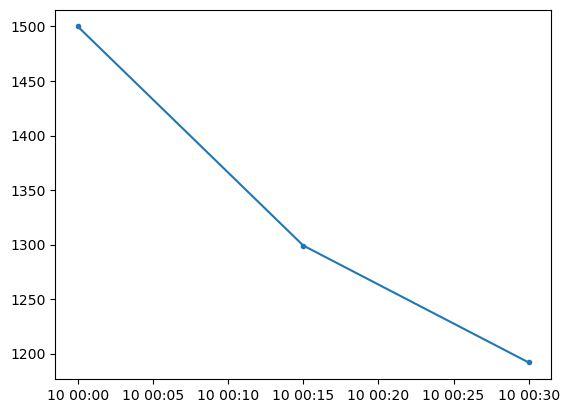

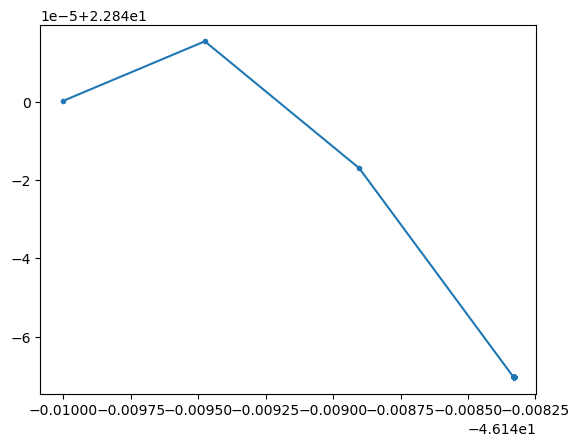

In [102]:
df = parcels.read_particlefile("output.parquet")

plt.plot(df["t"], df["z"], '.-')
plt.show()

plt.plot(df["x"], df["y"], '.-')
plt.show()

(1500.0, 0.0)

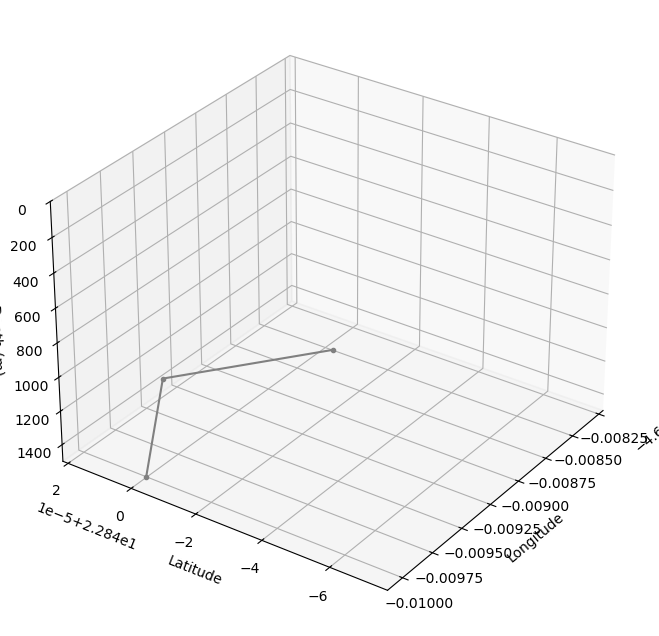


















Integration time: 2025-06-11T23:45:00  67%|██████▋   | [00:23<00:02, 36461.39it/s]

In [103]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection="3d")
ax.view_init(azim=-145)
ax.plot3D(df["x"], df["y"], df["z"], '.-', color="gray")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Depth (m)")
ax.set_zlim(df["z"].max(), 0)

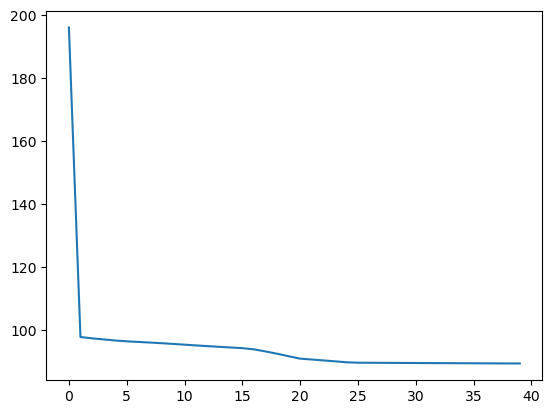

In [18]:
plt.plot(np.diff(df["z"]))
plt.show()